# Passive source example

<a target="_blank" href="https://colab.research.google.com/github/DASDAE/ctemps_tutorial/blob/master/05_patch.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

#### Useful links: 
* [Colab link](https://colab.research.google.com/github/DASDAE/ctemps_tutorial/blob/master/05_patch.ipynb)
* [DASCore documentation](https://dascore.org)



In [1]:
## %%capture

# First ensure DASCore is installed. If not, install and restart the kernel.
try:
    import dascore as dc
except ImportError:
    !pip install dascore
    !pip install ipympl
    # resetart kernel
    import IPython
    IPython.Application.instance().kernel.do_shutdown(True) #automatically restarts kernel

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# helper function to flip patch
def flip_and_patchify(patch):
    """
    flips the input patch along the distance axis, extracts the data, then creates a new patch from the flipped input
    Using this because the flip function within dascore is not working as expected currently
    
    Parameters
    ----------
    patch: DASCore Patch
        
    data_name: String
        The name of the input 2d array
    fs: Int
        Original sampling frequency of raw data

    Returns
    -------
    pa: DASCore Patch
        The Patch format of the input array for use with DASCore
    """ 
    #attributes/metadata for patch
    attrs = patch.attrs

    dat = patch.flip("distance").data #flip data array here

    time_start = patch.coords.min("time")
    time_step = dc.to_timedelta64(patch.coords.step("time"))
    time = time_start + np.arange(dat.shape[0]) * time_step

    distance_start = patch.coords.min("distance")
    distance_step = patch.coords.step("distance")
    distance = distance_start + np.arange(dat.shape[1]) * distance_step

    coords = dict(time=time, distance = distance)

    dims = ('time', 'distance')

    pa = dc.Patch(data = dat, coords = coords, attrs = attrs, dims = dims)
    return pa

## Load in spool

In [3]:
spool = dc.spool('/Users/nikhil_punithan/Desktop/PhD/CTEMPS26/ctemps_tutorial/Test_data') # create a spool from data directory
patch = spool[0] # isolate the first patch from 
patch.get_coord # print out patch coords

<bound method get_coord of DASCore Patch ⚡
---------------
➤ Coordinates (time: 12364, distance: 404)
    *time: CoordRange( min: 2022-01-15T18:19:06.867960064 max: 2022-01-15T18:21:10.500667561 step: 0.010000219s shape: (12364,) dtype: datetime64[ns] units: s )
    *distance: CoordRange( min: 9.61 max: 9.97e+02 step: 2.45 shape: (404,) dtype: float64 units: m )
➤ Data (float32, units: 1.0 m / s)
   [[0.001 0.001 0.001 ... 0.001 0.001 0.001]
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]
    ...
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]
    [0.001 0.001 0.001 ... 0.001 0.001 0.001]]
➤ Attributes
    data_type: velocity
    data_units: m / s
    instrument_id: T216113
    pulse_rate: 2.24e+04
    pulse_length: 9.8
    gauge_length: 9.8
>

## Raw data exploration
- visualize different subsections

- visualize spectra

- experiment with different filtering strategies

<Axes: xlabel='distance(m)', ylabel='time'>

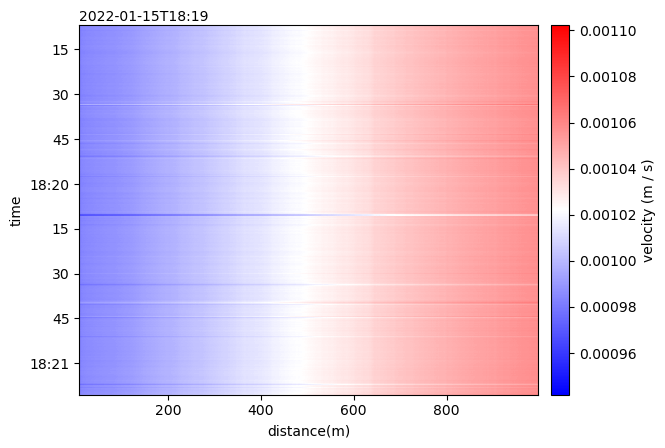

In [4]:
patch.viz.waterfall()

### Exercise 1 (data filtering and selection)

1. transform the patch from units of velocity (m/s) to strain rate
2. detrend across both axes
3. visualize output

<Axes: xlabel='distance(m)', ylabel='time'>

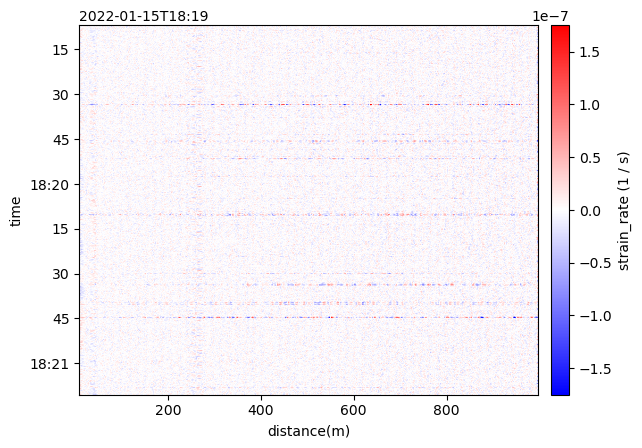

In [5]:
## your code here
patch_sr = patch.velocity_to_strain_rate()
patch_dt1 = patch_sr.detrend("time")
patch_dt2 = patch_dt1.detrend("distance")
patch_dt2.viz.waterfall()

<Axes: xlabel='distance(m)', ylabel='time'>

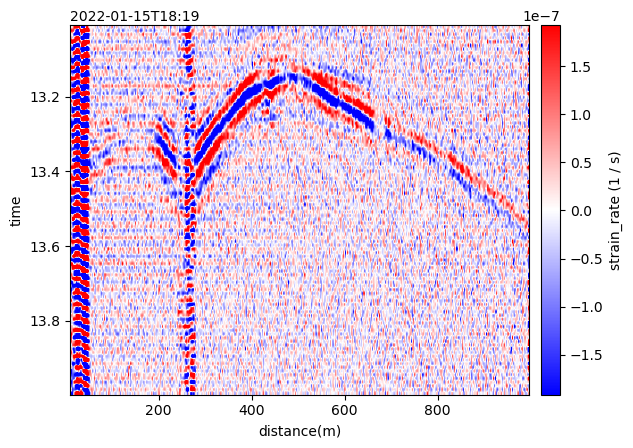

In [6]:
patch_sel = patch_dt2.select(time = ('2022-01-15T18:19:13', '2022-01-15T18:19:14'))
patch_sel.viz.waterfall()

<Axes: xlabel='distance(m)', ylabel='time'>

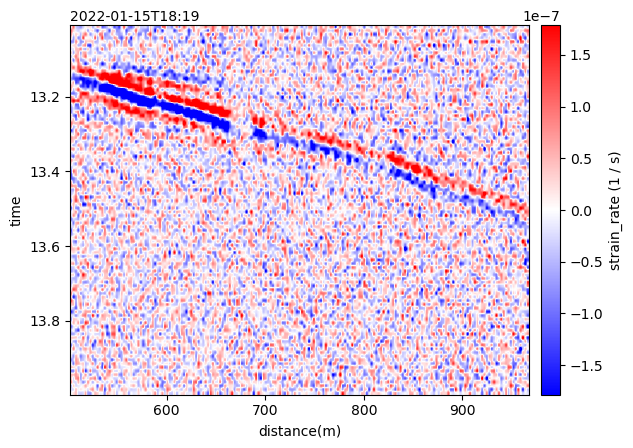

In [22]:
patch_sel_r = patch_sel.select(distance = (500, 970))
patch_sel_r.viz.waterfall()

<Axes: xlabel='distance(m)', ylabel='time'>

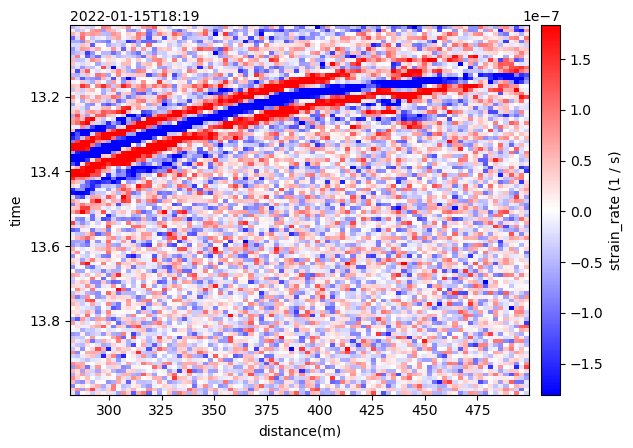

In [23]:
patch_sel_l = patch_sel.select(distance = (280, 500))
patch_sel_l.viz.waterfall()

## Surface wave dispersion

Text(0, 0.5, 'amplitude')

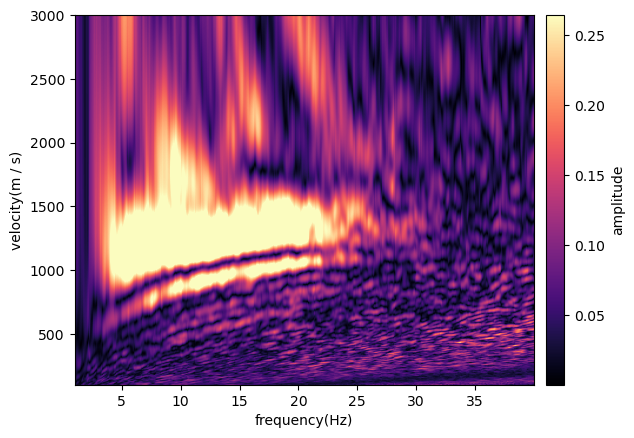

In [24]:
dsp = patch_sel_r.dispersion_phase_shift(np.arange(100,3000,1),
        approx_resolution=0.1,approx_freq=[1,40])

ax = dsp.viz.waterfall(cmap = 'magma')
plt.ylim(100, 3000)

plt.gcf().axes[-1].set_ylabel("amplitude")

Text(0, 0.5, 'amplitude')

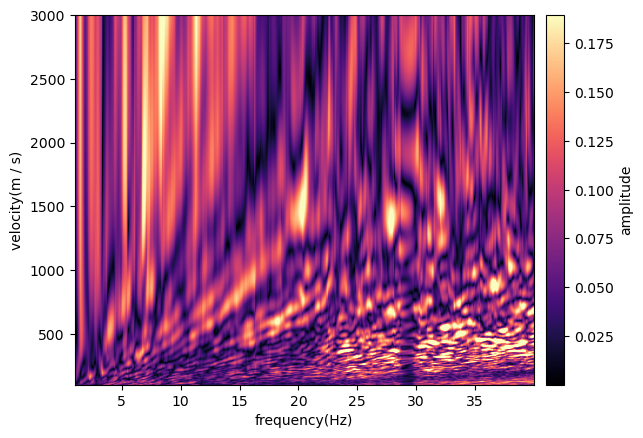

In [25]:
dsp = patch_sel_l.dispersion_phase_shift(np.arange(100,3000,1),
        approx_resolution=0.1,approx_freq=[1,40])

ax = dsp.viz.waterfall(cmap = 'magma')
plt.ylim(100, 3000)

plt.gcf().axes[-1].set_ylabel("amplitude")

<Axes: xlabel='distance', ylabel='time'>

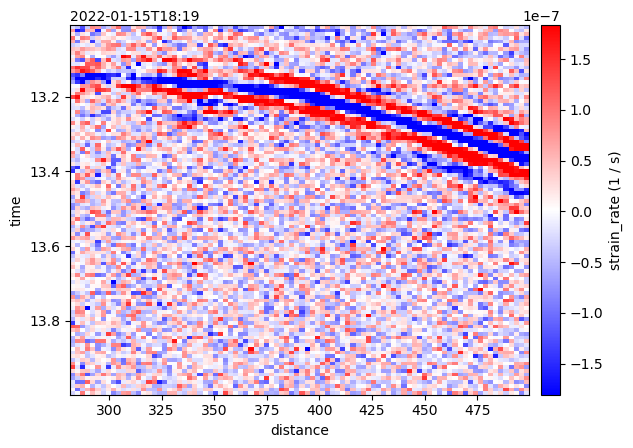

In [ ]:
f_patch_sel_l = flip_and_patchify(patch_sel_l)

f_patch_sel_l.viz.waterfall()

Text(0, 0.5, 'amplitude')

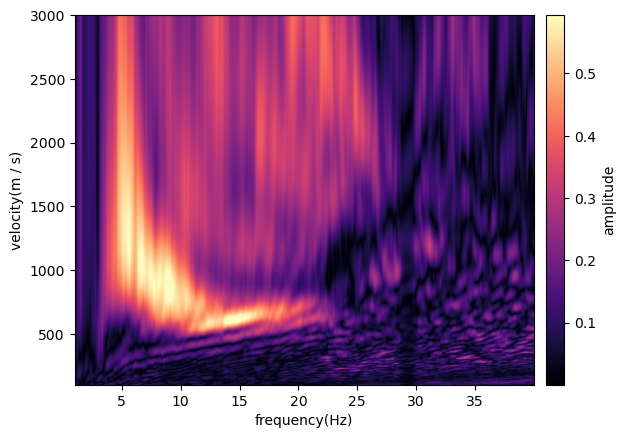

In [ ]:
dsp = f_patch_sel_l.dispersion_phase_shift(np.arange(100, 3000,1),
        approx_resolution=.1,approx_freq=[1,40])

ax = dsp.viz.waterfall(cmap = 'magma')
plt.ylim(100, 3000)

plt.gcf().axes[-1].set_ylabel("amplitude")